# 🌍 World Happiness Report Analysis – 2015

### 📌 Objective:
This project explores the global happiness rankings of countries based on social, economic, and health-related factors. Using the 2015 World Happiness dataset, we will:

- 📊 Visualize the **Top 10 happiest** and **Bottom 10 least happy** countries
- 💰 Explore the relationship between **GDP per Capita** and **Happiness Score**
- 🌐 Compare **region-wise average happiness scores**
- 🧠 Understand correlations via a **heatmap**

### 📁 Dataset Source:
- [World Happiness Report 2015 – Kaggle](https://www.kaggle.com/datasets/unsdsn/world-happiness)
- Dataset renamed to: `happiness.csv`

In [2]:
#importing libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Loading the dataset:
df = pd.read_csv('happiness.csv')
df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [4]:
#checking for null values:
df.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [5]:
#checking short description of the dataset:
print(df.describe())
print("\n")
print(df.info())

       Happiness Rank  Happiness Score  Standard Error  \
count      158.000000       158.000000      158.000000   
mean        79.493671         5.375734        0.047885   
std         45.754363         1.145010        0.017146   
min          1.000000         2.839000        0.018480   
25%         40.250000         4.526000        0.037268   
50%         79.500000         5.232500        0.043940   
75%        118.750000         6.243750        0.052300   
max        158.000000         7.587000        0.136930   

       Economy (GDP per Capita)      Family  Health (Life Expectancy)  \
count                158.000000  158.000000                158.000000   
mean                   0.846137    0.991046                  0.630259   
std                    0.403121    0.272369                  0.247078   
min                    0.000000    0.000000                  0.000000   
25%                    0.545808    0.856823                  0.439185   
50%                    0.910245    1.02

In [6]:
#checking how many countries per region
df['Region'].value_counts()

Region
Sub-Saharan Africa                 40
Central and Eastern Europe         29
Latin America and Caribbean        22
Western Europe                     21
Middle East and Northern Africa    20
Southeastern Asia                   9
Southern Asia                       7
Eastern Asia                        6
North America                       2
Australia and New Zealand           2
Name: count, dtype: int64

## Exploratory Data Analysis(EDA)
- Visualizing and Comparing in various aspects
- Finding out top 10 happiest countries
- Finding out less 10 happy countries

In [8]:
#Finding out top 10 happiest countries
top_10 = df.sort_values(by='Happiness Score', ascending=False).head(10)
print(top_10[['Country', 'Happiness Score']])

       Country  Happiness Score
0  Switzerland            7.587
1      Iceland            7.561
2      Denmark            7.527
3       Norway            7.522
4       Canada            7.427
5      Finland            7.406
6  Netherlands            7.378
7       Sweden            7.364
8  New Zealand            7.286
9    Australia            7.284


C:\Users\User\AppData\Local\Temp\ipykernel_2256\848926227.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Happiness Score', y='Country', palette='viridis')


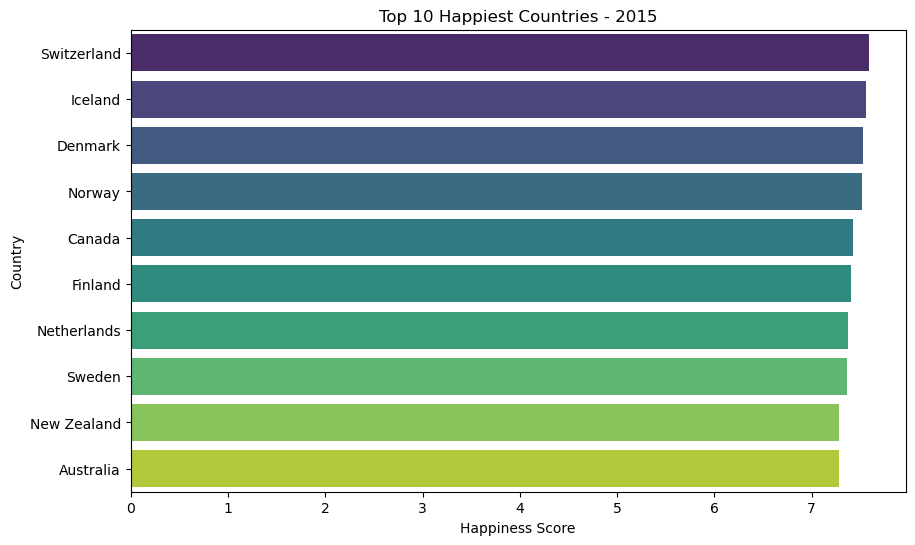

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_10, x='Happiness Score', y='Country', palette='viridis')
plt.title("Top 10 Happiest Countries - 2015")
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.show()

In [10]:
## Finding Out Bottom 10 Least Happy Countries
bottom_10 = df.sort_values(by='Happiness Score', ascending=True).head(10)
print(bottom_10[['Country', 'Happiness Score']])

          Country  Happiness Score
157          Togo            2.839
156       Burundi            2.905
155         Syria            3.006
154         Benin            3.340
153        Rwanda            3.465
152   Afghanistan            3.575
151  Burkina Faso            3.587
150   Ivory Coast            3.655
149        Guinea            3.656
148          Chad            3.667


C:\Users\User\AppData\Local\Temp\ipykernel_2256\2868455613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x='Happiness Score', y='Country', palette='viridis')


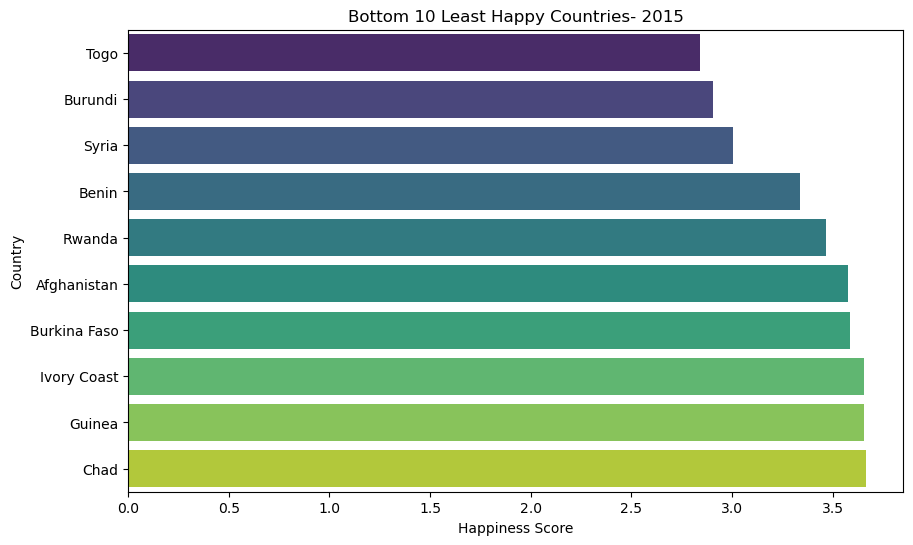

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(data=bottom_10, x='Happiness Score', y='Country', palette='viridis')
plt.title("Bottom 10 Least Happy Countries- 2015")
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.show()

## Correlation Heatmap

- To focus on how happiness score relates to:

> GDP per capita

>Health (Life Expectancy)

>Freedom

>Trust

>Family

- Then we find out that Happiness Score is highly dependent on a country's GDP, Health, and Family

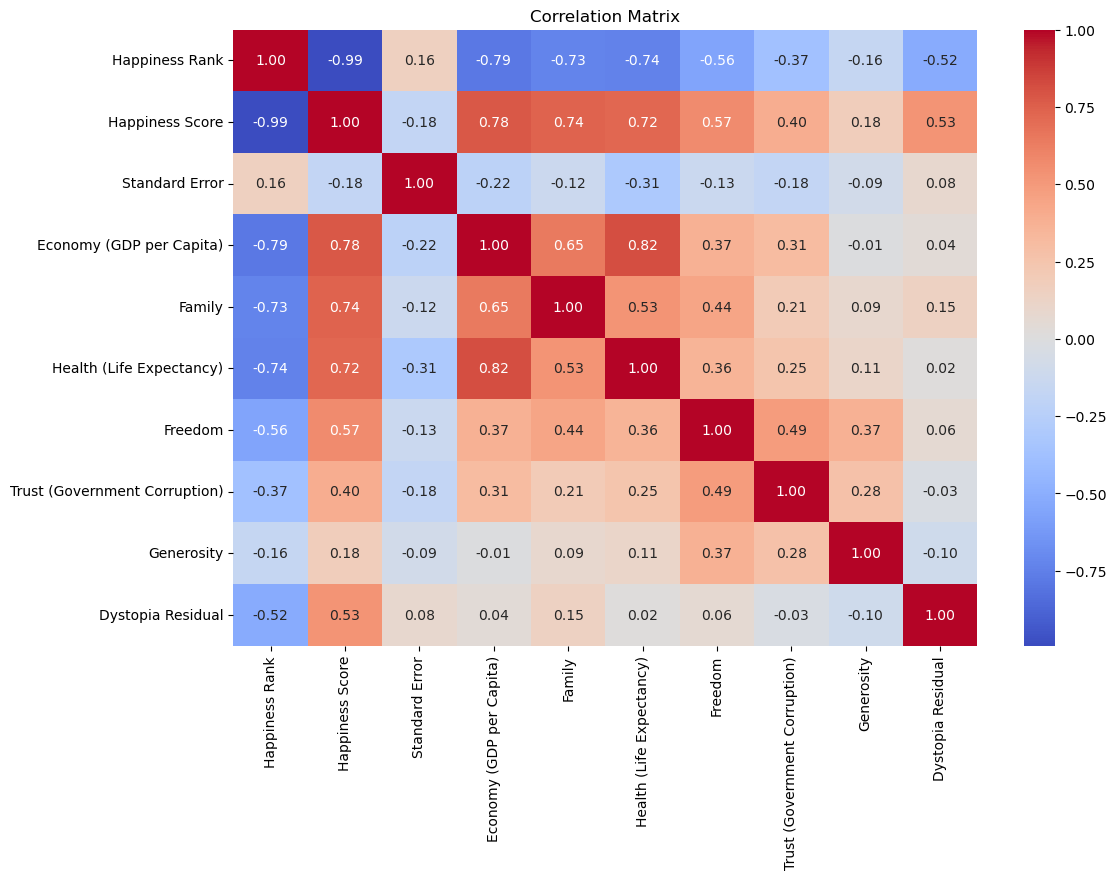

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

## GDP vs Happiness
- We observe that GDP per capita has a strong positive correlation with happiness score, indicating wealthier countries tend to have happier populations.

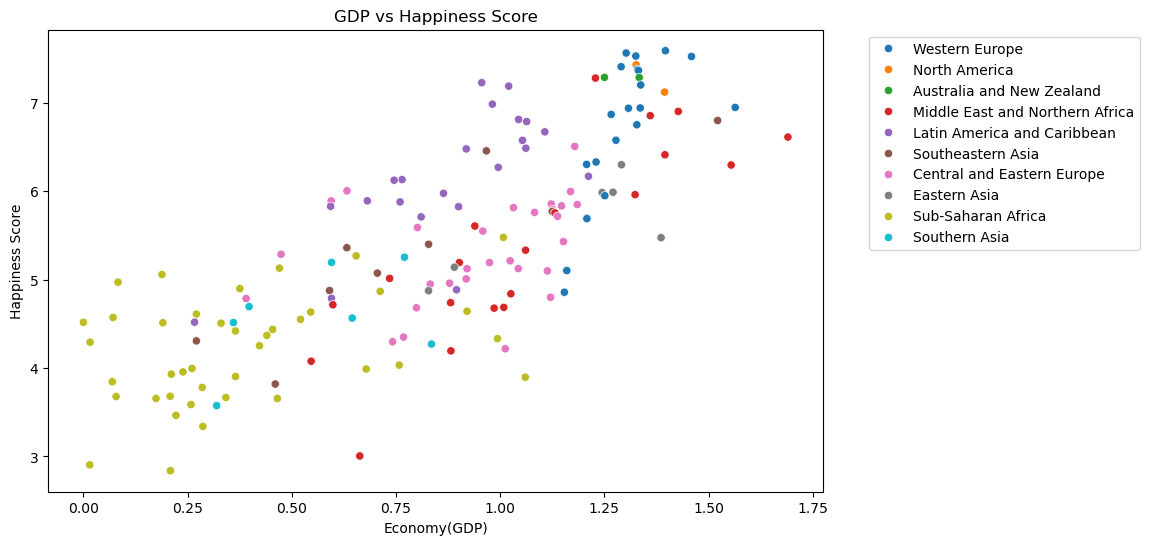

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score', hue='Region')
plt.title("GDP vs Happiness Score")
plt.xlabel("Economy(GDP)")
plt.ylabel("Happiness Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Region-Wise Mean Happiness
- We can see that Australia and New Zealand as well North America regions got the most average happiness score.

C:\Users\User\AppData\Local\Temp\ipykernel_2256\2752022501.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_mean.values, y=region_mean.index, palette='coolwarm')


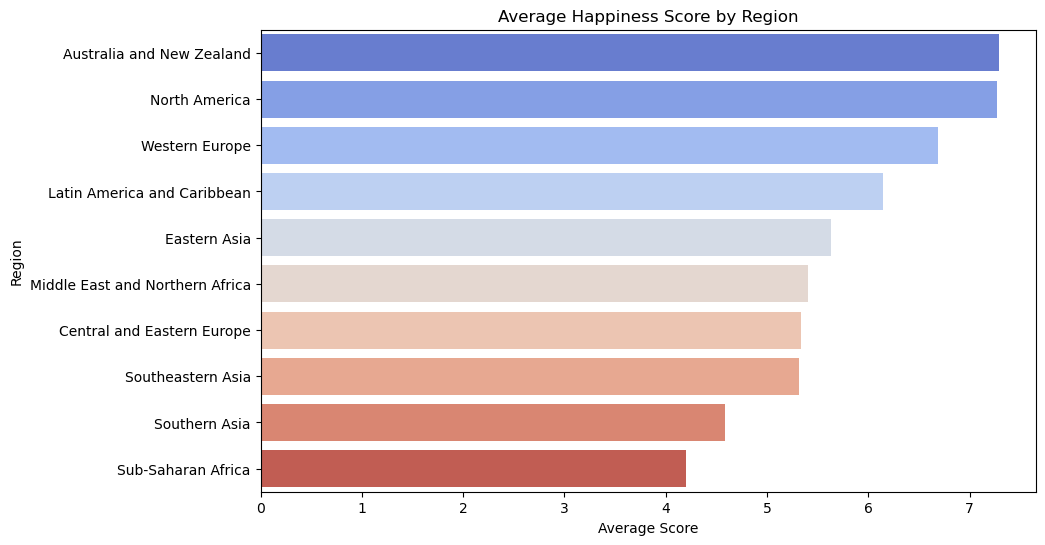

In [17]:
region_mean = df.groupby('Region')['Happiness Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=region_mean.values, y=region_mean.index, palette='coolwarm')
plt.title('Average Happiness Score by Region')
plt.xlabel('Average Score')
plt.ylabel('Region')
plt.show()